# HD Integrated Visium Interactive Suite (HiVis) - Plotting
This Notebook describes the various plotting methods and parameters available in both bin and aggregation levels.

We will use the HiVis object from [previous notebook]().

To see a details explanation and parameters for each function, visit the [documentation](https://hivis.readthedocs.io/latest/).

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
from HiVis import HiVis

sys.path.append(os.path.abspath(".."))

path = 'output/mouse_intestine.pkl'
si = HiVis.load(path) 
sub = HiVis.load('output/mouse_intestine_subset.pkl') 

## General arguments
All plots have few arguments that can be specified:
* **layer** - refers to the layer in the adata the gene expression should be taken from. If None, will use adata.X
* **save** - save the plot. It will be saved in the self.path_output directory, and will include the type of plot and the name of what is being plotted.
* **ax**, **figsize** - if ax is passed, the plot will be added to the passed ax. If not, a new figure will be created with the figsize specified.
* **cmap** - changes the colors of the plot. Can be from [matplotlib built-in colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html), a list of colors, or in categorical data case - a dictionary of {value:color}. Examples will be shown along this notebook.
* **title** - title of the plot.
* **xlab**, **ylab** - customizes the axis labels. In all plots except spatial, umap and cells.
* **legend** - changes if legend is shown or not

All plots return ax object.

## Saving of figures
Saving single ax is as simple as just specifying save=True in the plotting functions.

However, if you want to save a figure (with subplots), or manually name an ax, you can use plot.save(figname).

You can either specify ax=ax, or fig=fig. You can also pass a pandas dataframe to the fig parameter, to save it as a CSV file.

Optional arguments are the format of file, the dpi and if you want to open the file after saving.

## Spatial plot
Works for both HiVis and Agg objects. Works for both H&E and fluorescence data, for detailed instruction for handling and recoloring fluorescence data visit the [fluorescence notebook]().

We can plot just the image. The default resolution of image depends on its size, so for better control we can specify the resolution we want to plot (lowres,highres,fullres).

<Axes: xlabel='Spatial 1 (µm)', ylabel='Spatial 2 (µm)'>

<Figure size 640x480 with 0 Axes>

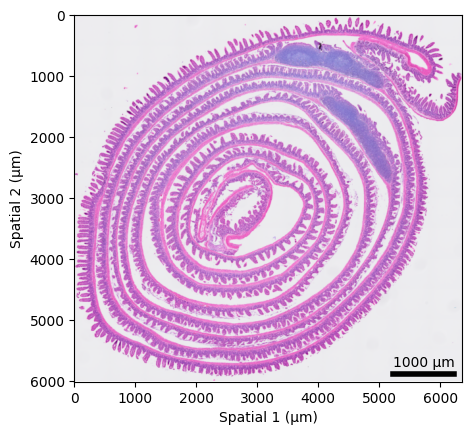

In [22]:
si.plot.spatial(figsize=(5,5),axis_labels=True)

We can zoom-in with xlim,ylim arguments.

Since all plots accept an ax argument, we can combine plots with plt.subplots() and pass specific ax to each.

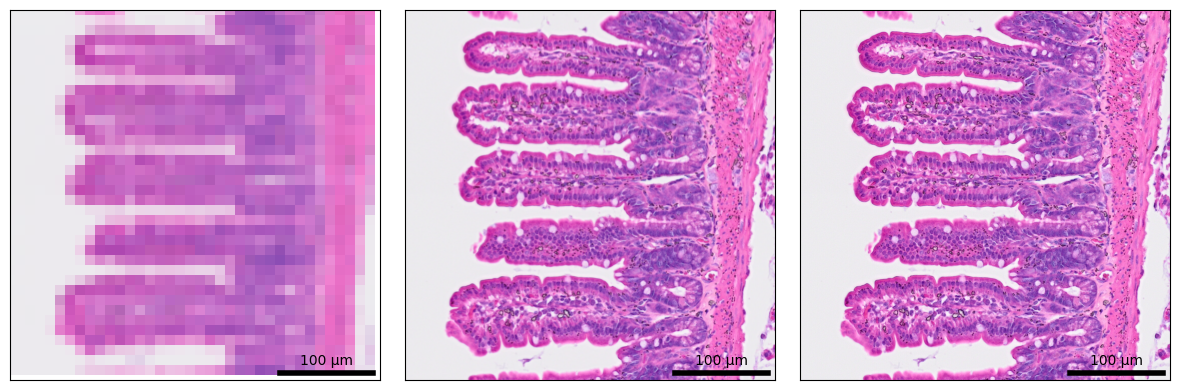

In [4]:
xlim=[0,400]
ylim=[3300,3700]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
si.plot.spatial(xlim=xlim,ylim=ylim,ax=axes[0],img_resolution="low")
si.plot.spatial(xlim=xlim,ylim=ylim,ax=axes[1],img_resolution="high")
si.plot.spatial(xlim=xlim,ylim=ylim,ax=axes[2],img_resolution="full")
plt.tight_layout()

We can also plot data from OBS, or gene expression level. Notice that fullsize plots (non cropped) take some time, since there are millions of bins that needs to be drawn.

In HiVis.plot.spatial(), when the exact size of bins is important (for publication quality plots), we can specify exact=True. This will render the exact size of the bins. the cost for this is rendering time (so for large image it may take few minutes).

In Aggregation.plot.spatial(), we can specify the size of spots.

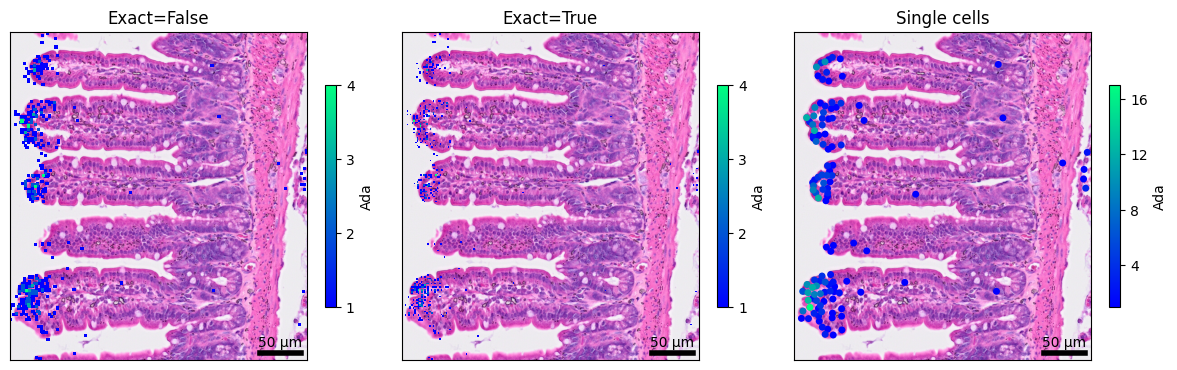

In [5]:
xlim=[50,300]
ylim=[3450,3700]
gene = "Ada"

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sub.plot.spatial(gene,ax=axes[0],exact=False,title="Exact=False")
sub.plot.spatial(gene,ax=axes[1],exact=True,title="Exact=True")
sub.agg["SC"].plot.spatial(gene,ax=axes[2],size=25,title="Single cells")
plt.tight_layout()

Lets see some general customisations for plots, and plotting of gene expression and bins-metadata

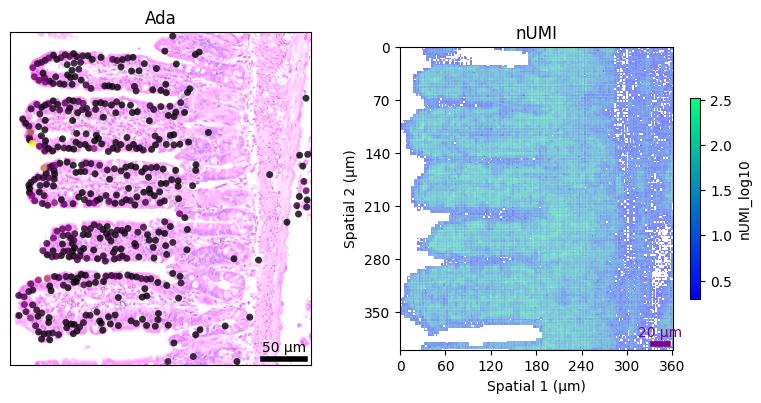

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8,4))
sub.agg["SC"].plot.spatial("Apob",size=25,title=gene,legend=False,
                brightness=1.5,contrast=0.7,cmap=["black","purple","yellow"],alpha=0.8,ax=axes[0])
sub.plot.spatial("nUMI_log10",exact=True,title="nUMI",legend=True,axis_labels=True,
             cmap="winter",alpha=0.5,ax=axes[1],image=False,scalebar={"color":"purple","length":20})
plt.tight_layout()

## Histogram
Works for both HiVis and Agg objects. Plots histogram of numeric values, or barplot of categorical values.

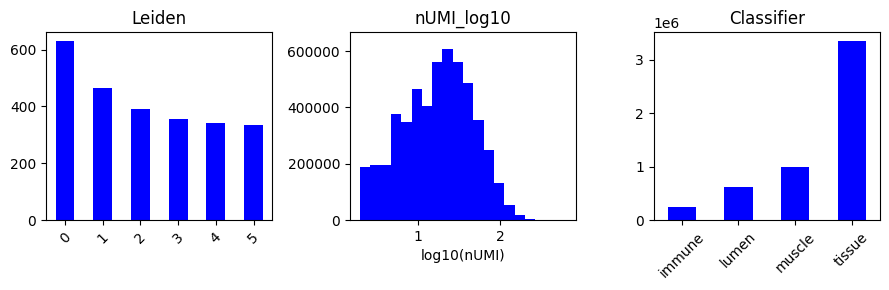

In [6]:
fig, axes = plt.subplots(1,3, figsize=(9,3))

sub.agg["SC"].plot.hist("leiden",ax=axes[0],title="Leiden")
si.plot.hist("nUMI_log10",ax=axes[1],xlab="log10(nUMI)")
si.plot.hist("muscle_villi_classifier",ax=axes[2],title="Classifier")
plt.tight_layout()

If we want to show only values in specific range, we can specify the xlim.

Additionally, if we run a spatial-plot with specific xlim,ylim, we can create a histogram in this ROI using cropped=True.

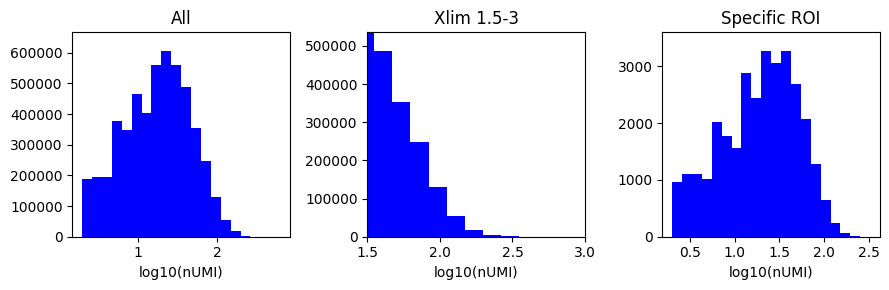

In [7]:
fig, axes = plt.subplots(1,3, figsize=(9,3))

si.plot.hist("nUMI_log10",ax=axes[0],xlab="log10(nUMI)",title="All")
si.plot.hist("nUMI_log10",ax=axes[1],xlab="log10(nUMI)",title="Xlim 1.5-3",xlim=[1.5,3])
si.plot.spatial(xlim=xlim,ylim=ylim); plt.close() # close the spatial if we don't want to show it in this case
si.plot.hist("nUMI_log10",ax=axes[2],xlab="log10(nUMI)",title="Specific ROI",cropped=True)
plt.tight_layout()

Lets see some general customisations for plots

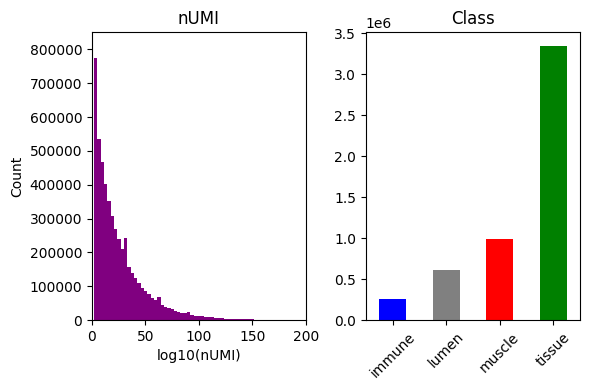

In [16]:
fig, axes = plt.subplots(1,2, figsize=(6,4))
si.plot.hist("nUMI",bins=200,xlab="log10(nUMI)",ax=axes[0],color="purple",ylab="Count",xlim=[0,200])
si.plot.hist("muscle_villi_classifier",ax=axes[1],cmap={"immune":"blue","muscle":"red","tissue":"green","lumen":"gray"},title="Class")
plt.tight_layout()

## Correlation plot
Works for both HiVis and Agg objects. Correlation is between a gene or a numeric OBS, with all genes.

Two types:
* If one value is passed, will show scatterplot of correlation of the value to all genes. If cor(inplace=True) has been run before, the plot will be instant. Otherwise it will calculate the correlation with inplace=True, which can take few minutes.
* If a list of values is specified, will show a heatmap - correlation matrix between genes.

Computing correlation with Igha: 100%|███████████████████████████████████████████| 3222/3222 [00:01<00:00, 1633.32it/s]


<Axes: title={'center': 'Igha'}, xlabel='log10(mean expression)', ylabel='Spearman correlation'>

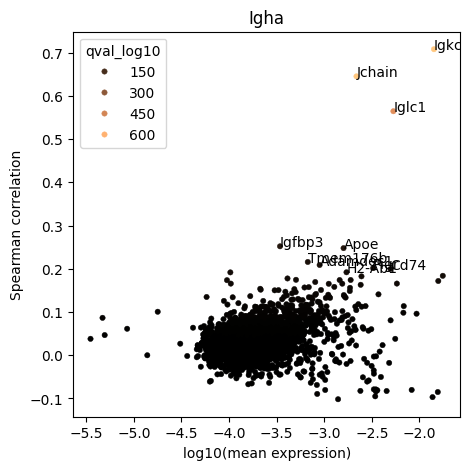

In [18]:
gene = "Igha"
sub.agg["SC"].plot.cor(gene, number_of_genes=10,cmap="copper",figsize=(5,5))

<Axes: >

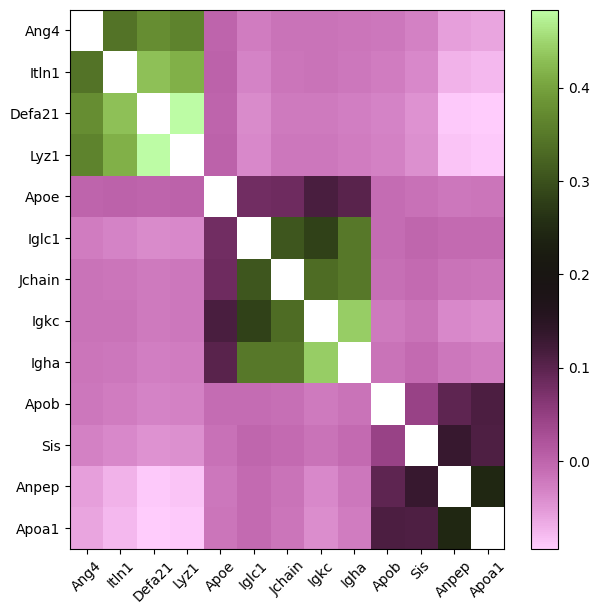

In [19]:
genes = ["Iglc1","Ang4","Defa21","Igkc","Jchain","Apoe","Anpep","Apoa1","Sis","Igha","Lyz1","Itln1","Apob"]
si.plot.cor(genes, cmap="vanimo", cluster=True)

## plot cells (shapes)
Only relevent for Aggregations, not HiVis. Plots the outlined shapes overlayed on the image.

C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\HiVis\HiVis_plot.py:833: RuntimeWarning: invalid value encountered in cast
  is_int = np.issubdtype(values.dtype, np.integer) or np.allclose(values, values.astype(int))


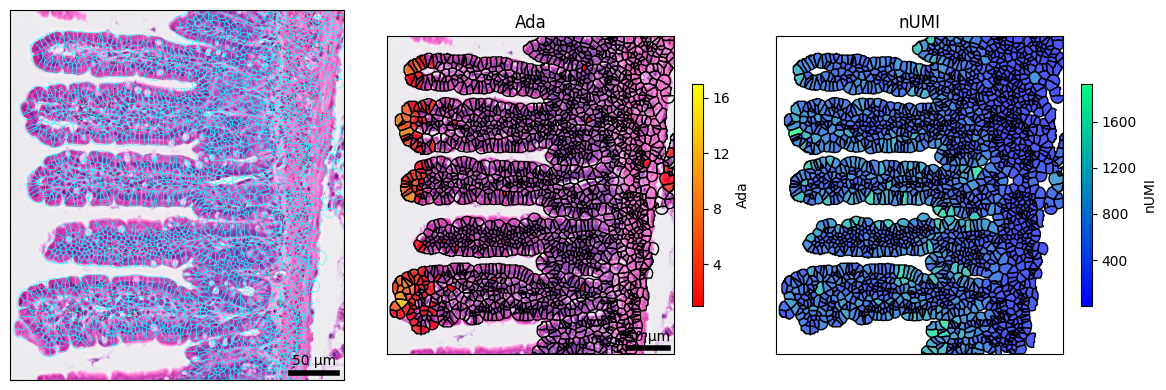

In [9]:
fig, axes = plt.subplots(1,3, figsize=(12,4))
sub.agg["SC"].plot.cells(ax=axes[0],line_color="cyan",linewidth=0.3)
sub.agg["SC"].plot.cells("Ada", ax=axes[1],cmap=["red","yellow"])
sub.agg["SC"].plot.cells("nUMI",ax=axes[2],image=False,scalebar=False,cmap="winter")
plt.tight_layout()

## Plot UMAP
Only relevent for Aggregations, not HiVis. Wrapper of scanpy.pl.umap.
*In this tutorial UMAP won't be shown, but here are examples for how you can call the umap function.

<Axes: title={'center': 'leiden'}, xlabel='X_umap1', ylabel='X_umap2'>

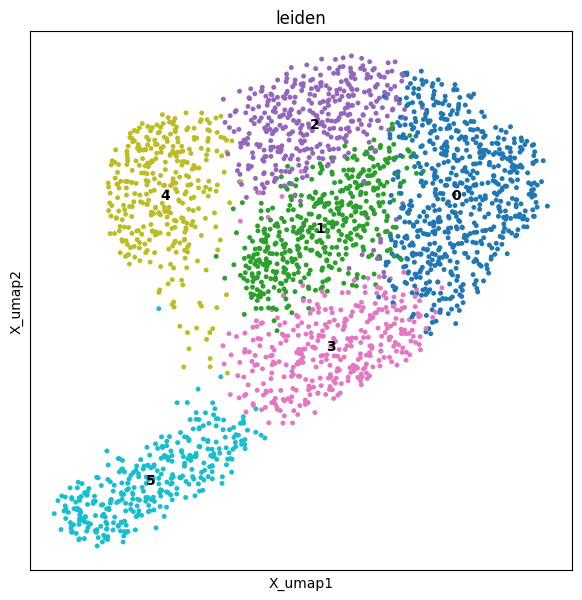

In [16]:
sub.agg["SC"].plot.umap("leiden",texts=True,legend=False,cmap="tab10",size=50)

<Axes: title={'center': 'Adaa'}>

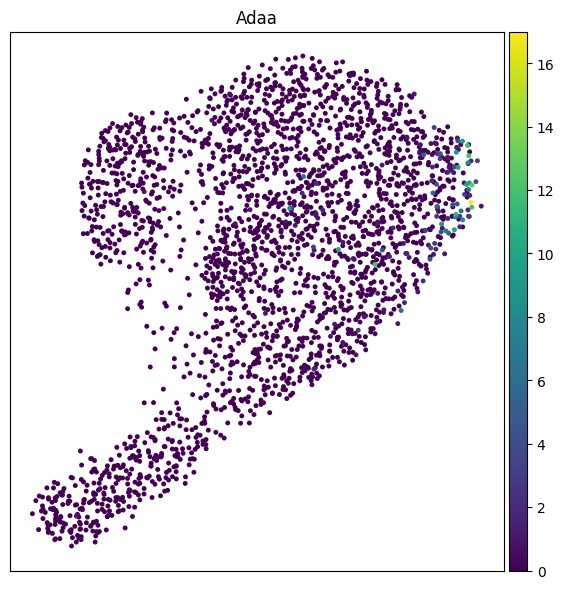

In [17]:
sub.agg["SC"].plot.umap("Ada",size=50,cmap=["black","orange"],axis_labels=False)

## Noise mean curve
Works for both HiVis and Agg objects. Shows how variable genes are. Genes that are further from the line are more variable.

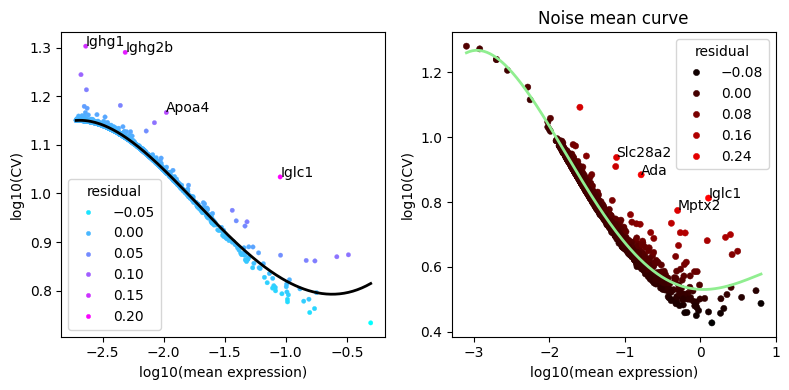

In [19]:
fig, axes = plt.subplots(1,2, figsize=(8,4))
si.plot.noise_mean_curve(ax=axes[0],fit_color="k")
sub.agg["SC"].plot.noise_mean_curve(ax=axes[1],cmap=["black","red"],size=20, signif_thresh=0.999, title="Noise mean curve",fit_color="lightgreen")
plt.tight_layout()

# Combination of plot
Since every plot return an ax, and accepts an ax argument, we can combine and overlay plots. This is especially usefull for spatial plots.

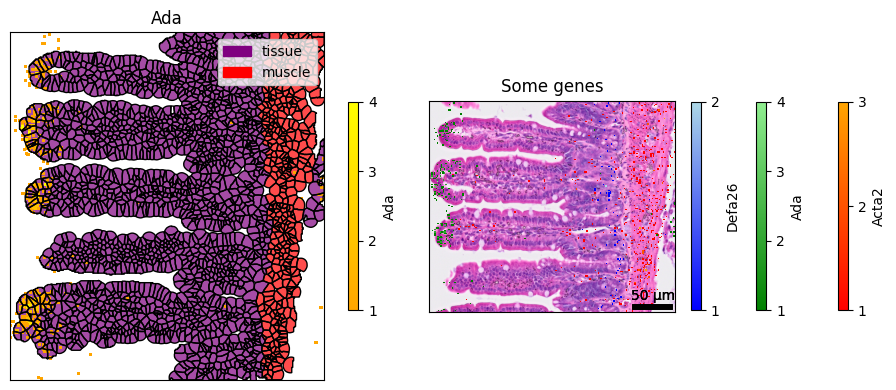

In [21]:
xlim = [50,400]
ylim = [3300,3600]

fig, axes = plt.subplots(1,2, figsize=(10,4))
ax = sub.agg["SC"].plot.cells("muscle_villi_classifier", ax=axes[0],image=False,scalebar=False,legend=False,
                             cmap={"lumen":"none","tissue":"purple","muscle":"red"})
HiVis.HiVis_plot.add_legend({"purple":"tissue","red":"muscle"},ax=ax)
sub.plot.spatial("Ada", ax=ax,cmap=["orange","yellow"],image=False,scalebar=False)
ax = si.plot.spatial("Acta2", xlim=xlim,ylim=ylim,ax=axes[1],cmap=["red","orange"],exact=True)
ax = si.plot.spatial("Ada", xlim=xlim,ylim=ylim,ax=ax,cmap=["green","lightgreen"],exact=True)
si.plot.spatial("Defa26", xlim=xlim,ylim=ylim,ax=ax,cmap=["blue","lightblue"],exact=True,title="Some genes")
plt.tight_layout()